## 留意事項
* 本資料は教育・情報提供を目的としたものであり、特定の暗号資産・金融商品の売買、投資行動を推奨または勧誘するものではありません。
* 本資料に含まれる見解、分析、シミュレーション等は作成時点の情報および過去データ等に基づくものであり、その正確性・完全性を保証するものではありません。また、将来の成果・価格動向・収益等を保証するものではありません。
* 外部サービス名・製品名の記載は例示であり、主催者またはビットバンク株式会社による推奨、提携、保証を意味するものではありません。

# 先物乖離 Part 2-3: 時間足での精緻化

**日程**: 2026年3月12日 20:00〜21:00  
**前回**: Part 2-2（3/12） コストを考慮した現実的検証  
**今回**: 日足 → 1時間足に変えて、エントリー/決済タイミングを精緻化  

### 前回までのおさらい
- Part 1: BTCの先物乖離Z-Score逆張り → コスト前Sharpe ≈ +1.0
- Part 2-1: アルトコイン362銘柄に展開 → 63%でSharpe > 0（コスト前）
- Part 2-2: 手数料を入れると何銘柄が生き残るか検証

### Part 2-2 の問い
日足では「1日1回」しかシグナルを見ません。  
実際には乖離は1時間ごと、1分ごとに変動しています。  
**もっと細かい時間軸で見たら、パフォーマンスは改善するのか？**

### 今回やること
1. Part 2-2 のコスト後 TOP 10 銘柄を対象に
2. 1時間足データ（直近2年分）を取得
3. 保持期間を 1h / 4h / 24h の3パターンで比較
4. コスト込みで「時間足にするとどう変わるか」を検証

---
## 環境設定

In [1]:
%pip install japanize-matplotlib -q

Note: you may need to restart the kernel to use updated packages.


In [2]:
import sys

sys.path.insert(0, ".")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

try:
    import japanize_matplotlib
except ImportError:
    pass

import warnings

warnings.simplefilter("ignore")

plt.rcParams.update(
    {
        "figure.facecolor": "white",
        "axes.grid": True,
        "grid.alpha": 0.3,
        "font.size": 11,
    }
)
print("準備完了")

準備完了


---
## なぜ時間足を変えるのか？

| | 日足（Part 2-1・2-2） | 短い足（今回） |
|---|---|---|
| シグナル頻度 | 1日1回 | 1時間 or 4時間ごと |
| エントリー精度 | 粗い（1日の中で大きく動くことも） | 細かい |
| データ量 | 少ない | 4〜24倍 |

**メリット**: 乖離が発生した「瞬間」により近いタイミングでエントリーできる  
**デメリット**: ノイズも多くなる可能性がある  

今回は 1h / 4h / 1d の3つの時間足で、それぞれネイティブのローソク足を使って検証します。

---
## 対象銘柄の選定

Part 2-1 のランキングから **TOP 10** を使います。  
このノートでは、事前生成済みのCSV（`../csv` もしくは `./results`）を読み込みます。  
このセクションでは検証対象銘柄を固定します。


In [4]:
from pathlib import Path


def find_csv_dir(required_files):
    candidates = [
        Path("."),
        Path("../csv"),
        Path("./csv"),
        Path("./results"),
        Path("results"),
    ]
    for d in candidates:
        if all((d / f).exists() for f in required_files):
            return d
    missing = ", ".join(required_files)
    raise FileNotFoundError(
        "必要CSVが見つかりません。"
        f"\n必要: {missing}"
        "\n探索先: ../csv, ./csv, ./results, results"
    )


CSV_DIR = find_csv_dir(
    [
        "altcoin_basis_backtest.csv",
        "altcoin_basis_tf_backtest.csv",
        "altcoin_basis_tf_pnl_top10.csv",
    ]
)

print(f"CSV読み込み先: {CSV_DIR}")

df_cost = pd.read_csv(CSV_DIR / "altcoin_basis_backtest.csv")
df_cost = df_cost.sort_values("sharpe", ascending=False).reset_index(drop=True)

TOP_N = 10
target_symbols = df_cost.head(TOP_N)["symbol"].tolist()

print(f"対象銘柄（Part 2-1 Sharpe TOP {TOP_N}）:")
for i, sym in enumerate(target_symbols):
    row = df_cost[df_cost["symbol"] == sym].iloc[0]
    print(
        f"  {i+1:>2}. {sym:<10s}  Sharpe(日足): {row['sharpe']:+.3f}  Vol: ${row['avg_volume_usd']/1e6:.1f}M"
    )

CSV読み込み先: .
対象銘柄（Part 2-1 Sharpe TOP 10）:
   1. KMNO        Sharpe(日足): +3.439  Vol: $2.9M
   2. MORPHO      Sharpe(日足): +3.288  Vol: $14.0M
   3. SYRUP       Sharpe(日足): +3.001  Vol: $14.0M
   4. NIL         Sharpe(日足): +2.920  Vol: $5.2M
   5. TRUMP       Sharpe(日足): +2.909  Vol: $154.4M
   6. BARD        Sharpe(日足): +2.906  Vol: $14.9M
   7. VELODROME   Sharpe(日足): +2.670  Vol: $3.8M
   8. PUMP        Sharpe(日足): +2.407  Vol: $54.3M
   9. ERA         Sharpe(日足): +2.042  Vol: $24.3M
  10. NEWT        Sharpe(日足): +2.000  Vol: $7.5M


対象銘柄を設定しました。次に時間足ごとの比較条件を確認します。


---
## パラメータ設定

1h / 4h / 1d で比較可能なようにパラメータを揃えます。


In [5]:
TIMEFRAME_CONFIGS = {
    "1h": {"timeframe": "1h", "zscore_window": 336, "periods_per_year": 8760},
    "4h": {"timeframe": "4h", "zscore_window": 84, "periods_per_year": 2190},
    "1d": {"timeframe": "1d", "zscore_window": 14, "periods_per_year": 365},
}
TAKER_FEE = 0.0004  # 0.04% / 片道
FROM_DATE = "2024-03-01"  # 直近約2年

print("=" * 60)
print("パラメータ")
print("=" * 60)
for label, cfg in TIMEFRAME_CONFIGS.items():
    print(f"  {label:>3s}足  Z-Score Window: {cfg['zscore_window']}本 = 14日")
print(f"  手数料          : Taker {TAKER_FEE*100:.2f}% / 片道")
print(f"  データ期間      : {FROM_DATE} 〜 現在（約2年）")

パラメータ
   1h足  Z-Score Window: 336本 = 14日
   4h足  Z-Score Window: 84本 = 14日
   1d足  Z-Score Window: 14本 = 14日
  手数料          : Taker 0.04% / 片道
  データ期間      : 2024-03-01 〜 現在（約2年）


各時間足で14日相当のWindowに揃えていることを確認しました。次に事前計算済みデータを読み込みます。


---
## 事前計算済みデータの読み込み

時間足（1h / 4h / 1d）のバックテスト結果をCSVから読み込みます。  
このノートではAPI取得や再計算は行いません。  
このセクションでは集計結果とPnL系列を準備します。


In [6]:
df_h = pd.read_csv(CSV_DIR / "altcoin_basis_tf_backtest.csv")
pnl_long = pd.read_csv(
    CSV_DIR / "altcoin_basis_tf_pnl_top10.csv",
    parse_dates=["date"],
)

required_h = {"symbol", "tf_label", "sharpe_net", "return_net", "win_net", "turnover_pct"}
missing_h = required_h - set(df_h.columns)
if missing_h:
    raise ValueError(f"altcoin_basis_tf_backtest.csv の列不足: {sorted(missing_h)}")

required_pnl = {"date", "symbol", "tf_label", "pnl_gross", "pnl_net"}
missing_pnl = required_pnl - set(pnl_long.columns)
if missing_pnl:
    raise ValueError(f"altcoin_basis_tf_pnl_top10.csv の列不足: {sorted(missing_pnl)}")

all_pnl = {}
for (sym, tf_label), sub in pnl_long.groupby(["symbol", "tf_label"]):
    tmp = sub.sort_values("date").set_index("date")
    all_pnl[(sym, tf_label)] = tmp[["pnl_gross", "pnl_net"]].copy()

# 既存可視化セル互換のため、timeframe別のシンボル一覧を構築
# 値は未使用なので空dictで十分

tf_data = {tf_label: {} for tf_label in TIMEFRAME_CONFIGS}
for _, row in df_h.iterrows():
    tf_data.setdefault(row["tf_label"], {})[row["symbol"]] = {}

print("読み込み完了")
print(f"  集計結果: {len(df_h)}パターン")
print(f"  PnL系列: {len(all_pnl)}系列")

読み込み完了
  集計結果: 30パターン
  PnL系列: 30系列


30パターン分の集計とPnL系列を読み込みました。次にロジックの位置づけを確認します。


---
## 読み込み結果の確認

10銘柄 × 3時間足 = 最大30パターンの結果が読み込まれていることを確認します。


In [7]:
print("時間足別の読み込み件数:")
for tf_label in TIMEFRAME_CONFIGS:
    sub = df_h[df_h["tf_label"] == tf_label]
    print(f"  {tf_label}: {len(sub)}パターン")

print(f"\n完了: {len(df_h)}パターン")

時間足別の読み込み件数:
  1h: 10パターン
  4h: 10パターン
  1d: 10パターン

完了: 30パターン


時間足ごとの件数が想定通りであることを確認できました。次に全体統計を比較します。


---
## 時間足別の比較: 全体統計

時間足ごとの平均成績を比較し、全体傾向を確認します。


In [8]:
print("=" * 60)
print("時間足別 全体統計（コスト後）")
print("=" * 60)
print()

for tf_label in TIMEFRAME_CONFIGS:
    sub = df_h[df_h["tf_label"] == tf_label]
    if len(sub) == 0:
        continue
    n_pos = (sub["sharpe_net"] > 0).sum()
    print(f"  【{tf_label}足】 {len(sub)}銘柄")
    print(f"    Sharpe(net) > 0  : {n_pos} / {len(sub)} ({n_pos/len(sub)*100:.0f}%)")
    print(f"    Sharpe(net) 平均 : {sub['sharpe_net'].mean():+.3f}")
    print(f"    Sharpe(net) 中央 : {sub['sharpe_net'].median():+.3f}")
    print(f"    累積Return 平均  : {sub['return_net'].mean():+.3f}")
    print(f"    勝率 平均        : {sub['win_net'].mean():.1f}%")
    print(f"    回転率 平均      : {sub['turnover_pct'].mean():.1f}%")
    print()

時間足別 全体統計（コスト後）

  【1h足】 10銘柄
    Sharpe(net) > 0  : 6 / 10 (60%)
    Sharpe(net) 平均 : -0.239
    Sharpe(net) 中央 : +0.231
    累積Return 平均  : -0.370
    勝率 平均        : 49.5%
    回転率 平均      : 32.9%

  【4h足】 10銘柄
    Sharpe(net) > 0  : 6 / 10 (60%)
    Sharpe(net) 平均 : +0.654
    Sharpe(net) 中央 : +1.010
    累積Return 平均  : +0.314
    勝率 平均        : 50.4%
    回転率 平均      : 36.8%

  【1d足】 10銘柄
    Sharpe(net) > 0  : 10 / 10 (100%)
    Sharpe(net) 平均 : +2.646
    Sharpe(net) 中央 : +2.794
    累積Return 平均  : +2.183
    勝率 平均        : 55.3%
    回転率 平均      : 42.8%



平均では1dが優位で、短い足ほどコストの影響を受けやすい傾向を確認できました。次に銘柄別Sharpeを比較します。


---
## 時間足別 Sharpe 比較（棒グラフ）

銘柄ごとに、時間足別のSharpe差を比較します。


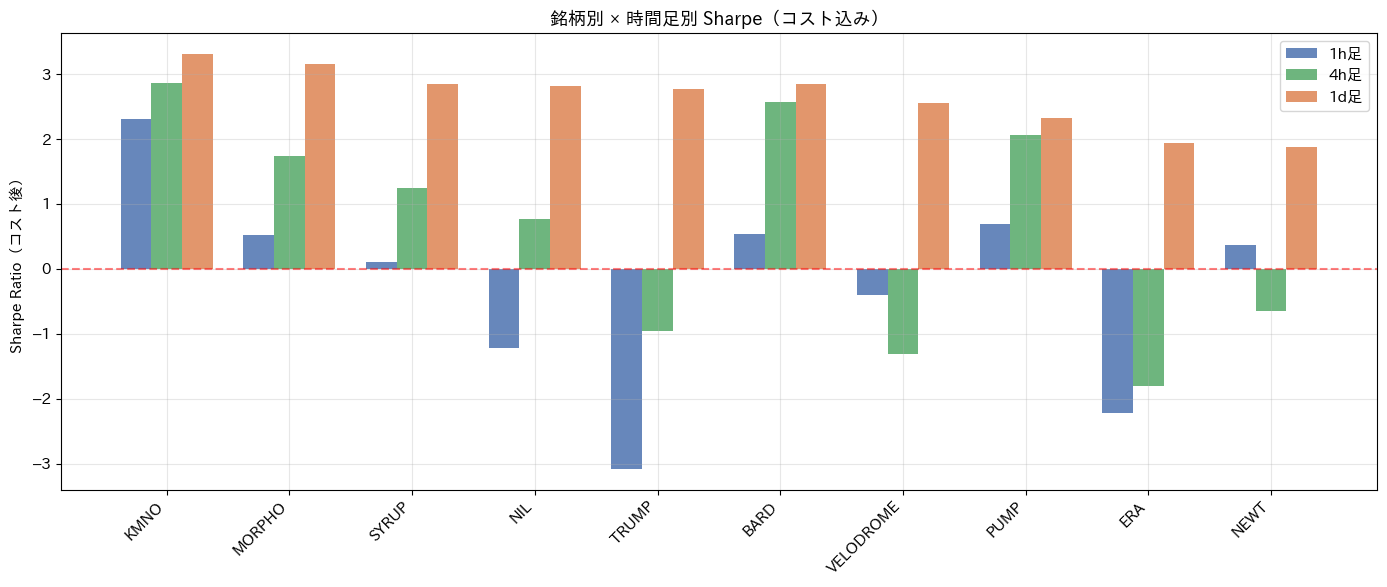

In [9]:
TF_LABELS = list(TIMEFRAME_CONFIGS.keys())
colors = ["#4C72B0", "#55A868", "#DD8452"]

pivot = df_h.pivot_table(index="symbol", columns="tf_label", values="sharpe_net")
pivot = pivot.reindex(columns=TF_LABELS)
pivot = pivot.reindex(target_symbols).dropna(how="all")

fig, ax = plt.subplots(figsize=(14, 6))

x = np.arange(len(pivot))
n_bars = len(TF_LABELS)
w = 0.25

for i, tf_label in enumerate(TF_LABELS):
    if tf_label in pivot.columns:
        vals = pivot[tf_label].fillna(0)
        ax.bar(
            x + (i - n_bars / 2 + 0.5) * w,
            vals,
            w,
            label=f"{tf_label}足",
            color=colors[i],
            alpha=0.85,
        )

ax.set_xticks(x)
ax.set_xticklabels(pivot.index, rotation=45, ha="right")
ax.set_ylabel("Sharpe Ratio（コスト後）")
ax.set_title("銘柄別 × 時間足別 Sharpe（コスト込み）", fontsize=13)
ax.axhline(0, color="red", linestyle="--", alpha=0.5)
ax.legend()
plt.tight_layout()
plt.show()

多くの銘柄で1d優位、4h中間、1h劣後の構図を確認できました。次に勝率を比較します。


---
## 時間足別の勝率比較

時間足ごとの勝率差を確認します。


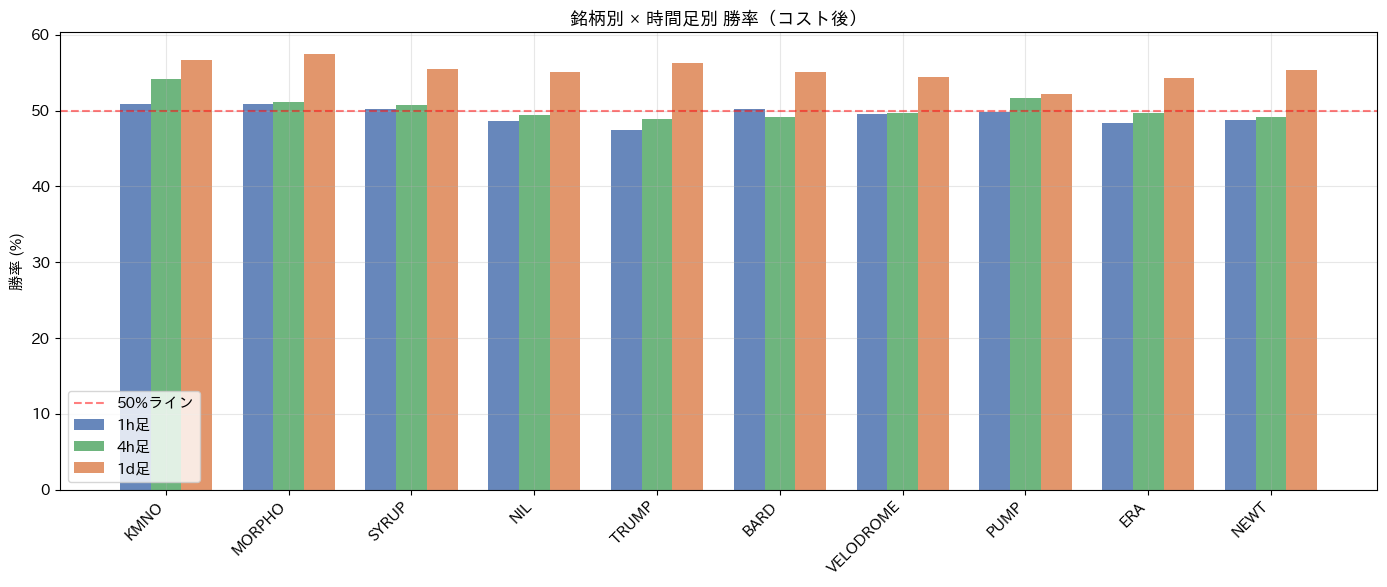

In [ ]:
# pivot_table はデータを集計して表形式に変換するもの
pivot_win = df_h.pivot_table(index="symbol", columns="tf_label", values="win_net")
pivot_win = pivot_win.reindex(columns=TF_LABELS)
pivot_win = pivot_win.reindex(target_symbols).dropna(how="all")

fig, ax = plt.subplots(figsize=(14, 6))

# arangeは連番の配列を作るメソッド。このコードではx軸に使っている
# np.arange(5)      # [0, 1, 2, 3, 4]
# np.arange(3, 8)   # [3, 4, 5, 6, 7]
# np.arange(0, 1, 0.2)  # [0.0, 0.2, 0.4, 0.6, 0.8]
# range() と似ているが、numpy配列を返すので数値計算に使える。また、rangeは整数のみ

x_win = np.arange(len(pivot_win))
for i, tf_label in enumerate(TF_LABELS):
    if tf_label in pivot_win.columns:
        vals = pivot_win[tf_label].fillna(50)
        ax.bar(
            x_win + (i - n_bars / 2 + 0.5) * w,
            vals,
            w,
            label=f"{tf_label}足",
            color=colors[i],
            alpha=0.85,
        )

ax.set_xticks(x_win)
ax.set_xticklabels(pivot_win.index, rotation=45, ha="right")
ax.set_ylabel("勝率 (%)")
ax.set_title("銘柄別 × 時間足別 勝率（コスト後）", fontsize=13)
ax.axhline(50, color="red", linestyle="--", alpha=0.5, label="50%ライン")
ax.legend()
plt.tight_layout()
plt.show()

勝率差は限定的ですが、Sharpe差は大きく、効率面で差が出ることを確認できました。次に回転率を確認します。


---
## 回転率と時間足の関係

短い足ほど「シグナルを見る回数」が多く、売買回数も増えます。  
このセクションでは、回転率とコスト負担の違いを確認します。


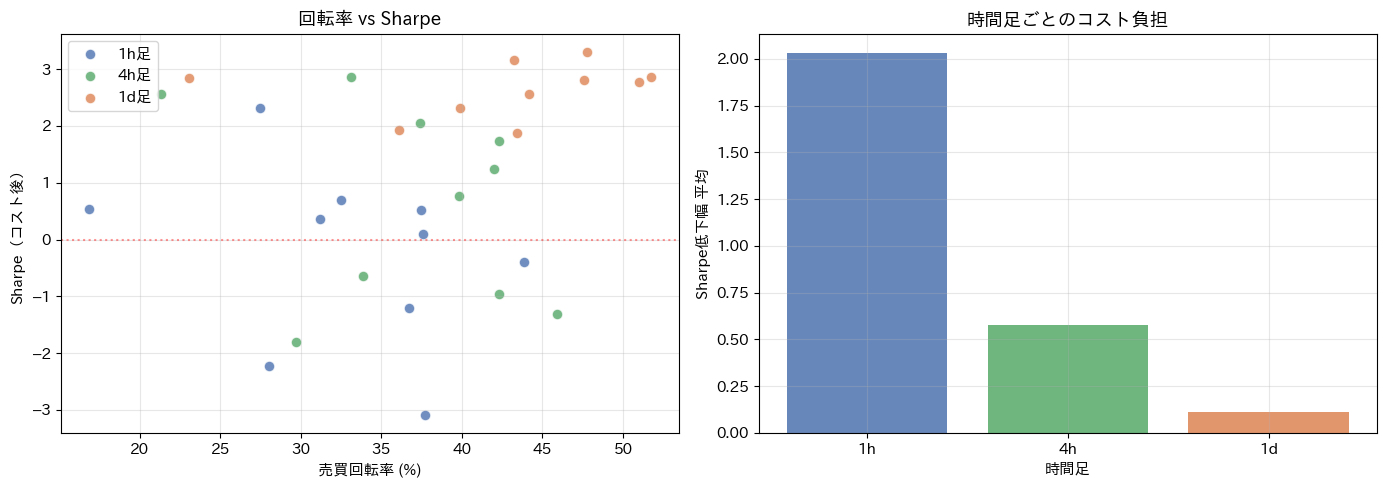

ポイント:
  短い足 → シグナル変化が頻繁 → 売買回数増 → コスト大
  長い足 → シグナル変化が少ない → 売買回数減 → コスト小
  → リターンとコストのバランスが重要


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
for tf_label, color in zip(TF_LABELS, colors):
    sub = df_h[df_h["tf_label"] == tf_label]
    ax.scatter(
        sub["turnover_pct"],
        sub["sharpe_net"],
        label=f"{tf_label}足",
        color=color,
        s=60,
        alpha=0.8,
        edgecolors="white",
    )
ax.set_xlabel("売買回転率 (%)")
ax.set_ylabel("Sharpe（コスト後）")
ax.set_title("回転率 vs Sharpe")
ax.axhline(0, color="red", linestyle=":", alpha=0.4)
ax.legend()

ax = axes[1]
sharpe_drop = df_h.copy()
sharpe_drop["cost_impact"] = sharpe_drop["sharpe_gross"] - sharpe_drop["sharpe_net"]
means = sharpe_drop.groupby("tf_label")["cost_impact"].mean().reindex(TF_LABELS)
ax.bar(TF_LABELS, means.values, color=colors[: len(means)], alpha=0.85)
ax.set_xlabel("時間足")
ax.set_ylabel("Sharpe低下幅 平均")
ax.set_title("時間足ごとのコスト負担")

plt.tight_layout()
plt.show()

print("ポイント:")
print("  短い足 → シグナル変化が頻繁 → 売買回数増 → コスト大")
print("  長い足 → シグナル変化が少ない → 売買回数減 → コスト小")
print("  → リターンとコストのバランスが重要")

短い足ほど回転率が高く、コスト負担が増えやすい傾向が明確でした。次にPnL曲線で確認します。


---
## TOP銘柄のPnL曲線（時間足別）

各銘柄について、1h / 4h / 1d の累積PnLを重ねて表示します。  
このセクションでは、同一銘柄で時間足別の累積PnLを比較します。


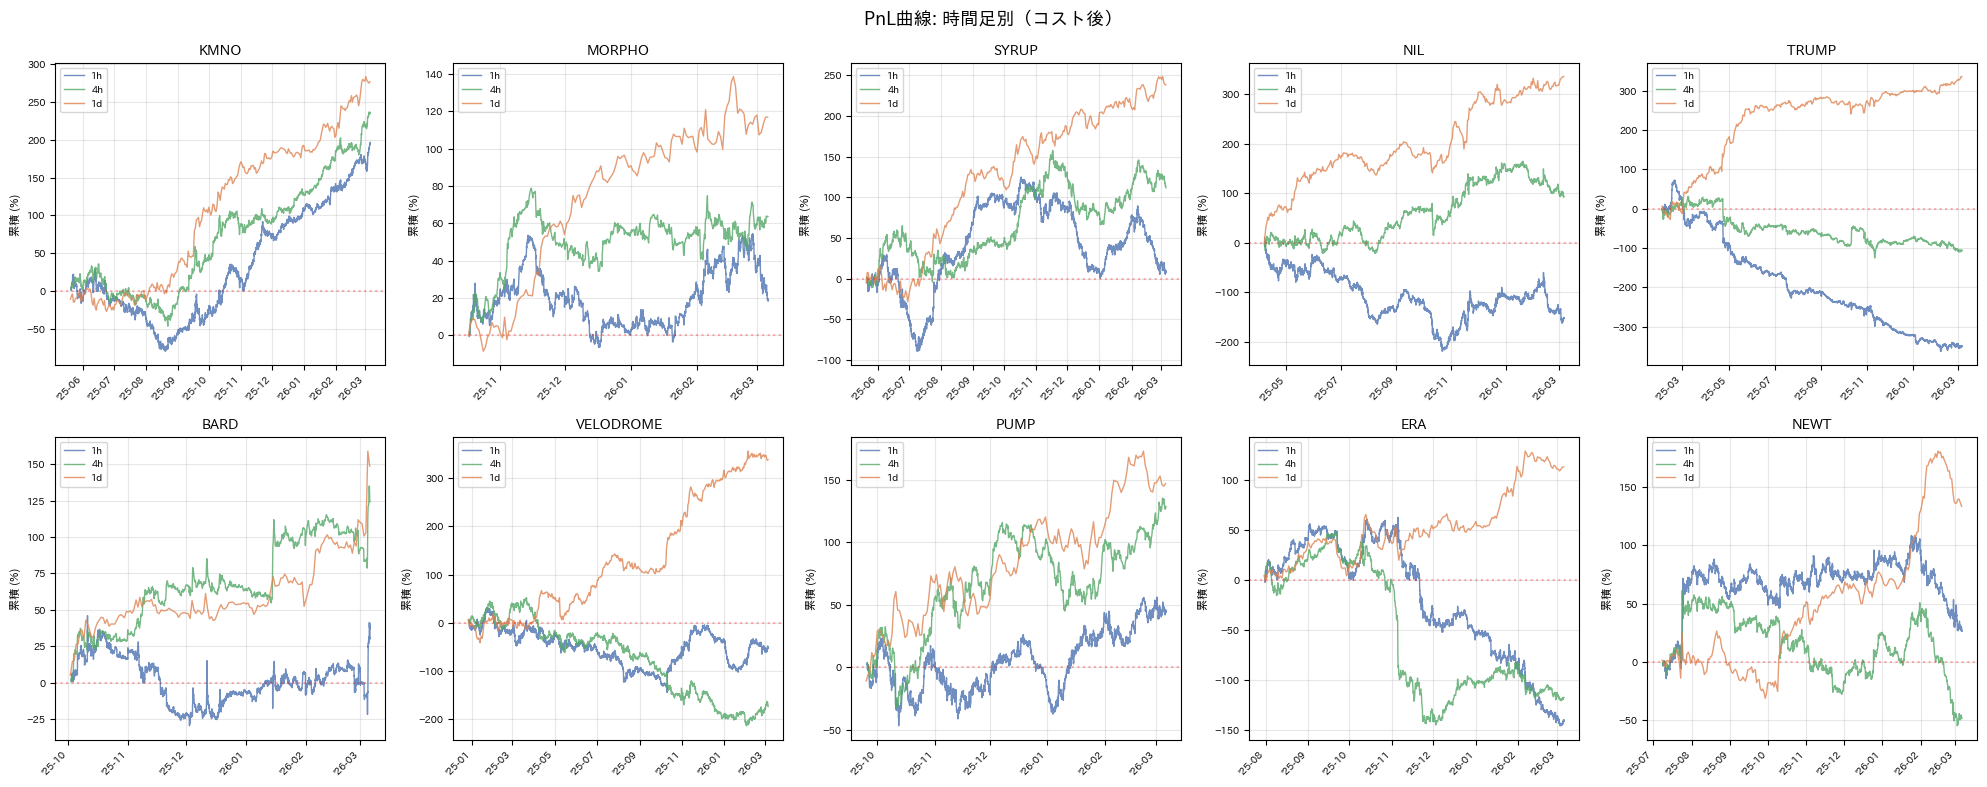

In [12]:
import matplotlib.dates as mdates

all_syms = set()
for tf_label in tf_data:
    all_syms.update(tf_data[tf_label].keys())
syms_with_data = [s for s in target_symbols if s in all_syms]
n_syms = len(syms_with_data)
ncols = min(5, n_syms)
nrows = (n_syms + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4 * nrows))
if n_syms == 1:
    axes = np.array([axes])
axes_flat = axes.flatten()

date_fmt = mdates.DateFormatter("'%y-%m")

for i, sym in enumerate(syms_with_data):
    ax = axes_flat[i]
    for tf_label, color in zip(TF_LABELS, colors):
        key = (sym, tf_label)
        if key in all_pnl:
            cum = all_pnl[key]["pnl_net"].cumsum() * 100
            ax.plot(cum.index, cum, label=f"{tf_label}", color=color, alpha=0.8, linewidth=1)
    ax.set_title(sym, fontsize=10)
    ax.legend(fontsize=7)
    ax.tick_params(labelsize=7)
    ax.set_ylabel("累積 (%)", fontsize=8)
    ax.axhline(0, color="red", linestyle=":", alpha=0.3)
    ax.xaxis.set_major_formatter(date_fmt)
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

for j in range(i + 1, len(axes_flat)):
    axes_flat[j].set_visible(False)

plt.suptitle("PnL曲線: 時間足別（コスト後）", fontsize=13)
plt.tight_layout()
plt.show()

PnL曲線でも時間足選択の差を確認できました。次にベスト時間足をランキングで確認します。


---
## ベスト時間足ランキング

各銘柄で、どの時間足が最もSharpeが高いかを確認します。  
このセクションでは、各銘柄でSharpeが最も高い時間足を抽出します。


In [13]:
best = (
    df_h.loc[df_h.groupby("symbol")["sharpe_net"].idxmax()]
    .sort_values("sharpe_net", ascending=False)
    .reset_index(drop=True)
)

print("=" * 60)
print("各銘柄のベスト時間足（Sharpe Net 最大）")
print("=" * 60)
print()
for _, row in best.iterrows():
    print(
        f"  {row['symbol']:<10s}  ベスト: {row['tf_label']:>3s}足  "
        f"Sharpe(net): {row['sharpe_net']:+.3f}  "
        f"Return: {row['return_net']:+.3f}  "
        f"Win: {row['win_net']:.1f}%"
    )

print()
tf_counts = best["tf_label"].value_counts().reindex(TF_LABELS).dropna().astype(int)
print("ベスト時間足の分布:")
for tf, cnt in tf_counts.items():
    print(f"  {tf:>3s}: {cnt}銘柄")

各銘柄のベスト時間足（Sharpe Net 最大）

  KMNO        ベスト:  1d足  Sharpe(net): +3.308  Return: +2.772  Win: 56.7%
  MORPHO      ベスト:  1d足  Sharpe(net): +3.156  Return: +1.170  Win: 57.4%
  SYRUP       ベスト:  1d足  Sharpe(net): +2.856  Return: +2.380  Win: 55.5%
  BARD        ベスト:  1d足  Sharpe(net): +2.852  Return: +1.487  Win: 55.1%
  NIL         ベスト:  1d足  Sharpe(net): +2.813  Return: +3.354  Win: 55.1%
  TRUMP       ベスト:  1d足  Sharpe(net): +2.776  Return: +3.358  Win: 56.3%
  VELODROME   ベスト:  1d足  Sharpe(net): +2.556  Return: +3.381  Win: 54.5%
  PUMP        ベスト:  1d足  Sharpe(net): +2.323  Return: +1.469  Win: 52.1%
  ERA         ベスト:  1d足  Sharpe(net): +1.934  Return: +1.129  Win: 54.3%
  NEWT        ベスト:  1d足  Sharpe(net): +1.883  Return: +1.334  Win: 55.4%

ベスト時間足の分布:
   1d: 10銘柄


今回の対象では1dがベストになる銘柄が多い結果でした。最後に学びをまとめます。


---
## まとめ

ここまでの比較結果を整理し、実運用での注意点を確認します。


In [ ]:
print("=" * 60)
print("先物乖離 Part 2-3: 時間足精緻化まとめ")
print("=" * 60)
print()
print(f"1. 検証条件")
print(f"   - 対象: Part 2-1 Sharpe TOP {TOP_N} 銘柄")
print(f"   - データ: {FROM_DATE} 〜 現在（約2年）")
print(f"   - 各足ネイティブ取得: 1h / 4h / 1d（Z-Score Window = 14日相当）")
print(f"   - 手数料: Taker {TAKER_FEE*100:.2f}% / 片道")
print()
print(f"2. 時間足別の結果")
for tf_label in TIMEFRAME_CONFIGS:
    sub = df_h[df_h["tf_label"] == tf_label]
    if len(sub) > 0:
        n_pos = (sub["sharpe_net"] > 0).sum()
        print(
            f"   - {tf_label:>3s}足: Sharpe平均 {sub['sharpe_net'].mean():+.3f}, "
            f"プラス {n_pos}/{len(sub)}銘柄"
        )
print()
if len(best) > 0:
    best_overall = best.iloc[0]
    print(f"3. ベストパフォーマンス")
    print(
        f"   - {best_overall['symbol']} {best_overall['tf_label']}足 "
        f"Sharpe(net): {best_overall['sharpe_net']:+.3f}"
    )
    print()
print(f"4. 学び")
print(f"   - 逆張り戦略はある程度の足の長さがないと平均回帰が効かない")
print(f"   - 短い足ほどシグナル評価回数が増え、コスト負担も増える")
print(f"   - 銘柄ごとに最適な時間足が異なる")
print()
print(f"5. 注意: TOP銘柄ほどデータが短い")
print(f"   - 今回のTOP 10は大半が上場1年未満の新しいコイン")
print(f"   - KITE: 4ヶ月、MORPHO/BARD: 5ヶ月、PUMP: 6ヶ月 など")
print(f"   - Sharpeが高く見えるのは、短期間の好調な相場を切り取っているだけかもしれない")
print(f"   - 長期データのある銘柄（BTC, ETH等）ではPart 1で見た通り効きが弱まっている")
print(f"   → 『短期間で高Sharpe = 良い戦略』とは限らない。過信は禁物")
print()
print(f"6. 今後の発展")
print(f"   - 他指標（出来高・ボラティリティ）との組み合わせ")
print(f"   - エントリー閾値の最適化（Z > 1.5 のみ等）")
print(f"   - リアルタイムシグナル配信の検討")

時間足の選択で成績とコスト負担が大きく変わることを確認できました。


## 免責事項
* 本資料の実行・利用により生成または保存されるデータの管理は利用者の責任で行ってください。
* お客様によるコンテンツの利用等に関して生じうるいかなる損害について責任を負いません。
* 執筆者によって提供されたいかなる見解または意見は当該執筆者自身のその時点における見解や分析であって、当社の見解、分析ではありません。
* 暗号資産（仮想通貨）は法定通貨ではありません。
* また、法定通貨とは異なり、日本円やドルなどのように国又は特定の者によりその価値を保証されているものではありません。
* 暗号資産の価格の変動等により損失が発生する可能性があります。
* 暗号資産は代価の弁済を受ける者の同意がある場合に限り、代価の弁済のために使用することができます。
* 暗号資産信用取引は、価格の変動等により当初差入れた保証金を上回る損失が発生する可能性があります。十分なご理解の上で、自己責任にてお取引ください。
* お取引を行う際には、弊社のWebサイトに記載の「契約締結前交付書面兼説明書」「各種規約」「取引ルール」をご確認のうえ、取引内容を十分に理解し、お客様ご自身の責任と判断を持って行ってください。